# Representative structure sampling

This notebook selects a small, reproducible subset from tracked UMA-generated NaCl structures. It compares k-means representative sampling with a random baseline, maps the selected feature rows back to XSF files, and checks how well each subset covers the standardized feature space.

Running the notebook requires `aenet[sampling]`, NumPy, scikit-learn, and Matplotlib. The tracked feature matrix was generated with the PyTorch featurization workflow documented in `data/NaCl-sampled-structures/README.md`; PyTorch is not needed for this sampling tutorial.

In [1]:
import tarfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler

from aenet.geometry.sampling import random_subset, representative_subset

RANDOM_SEED = 42
NUM_CANDIDATES = 100
NUM_SELECTED = 20

notebook_dir = (
    Path(".") if Path("data/NaCl-sampled-structures").exists()
    else Path("notebooks")
)
data_dir = notebook_dir / "data" / "NaCl-sampled-structures"
feature_path = data_dir / "sampled_structure_features.npz"
archive_path = data_dir / "sampled_structures.tar.xz"
output_dir = notebook_dir / "example-09-outputs" / "selected-structures"

## Load the candidate representations

The feature archive contains one 60-component global-moment representation and one archive-relative XSF name for each of 20,000 structures. The first 100 rows form a balanced demonstration set with 25 snapshots from each temperature.

In [2]:
with np.load(feature_path, allow_pickle=False) as data:
    features = data["features"][:NUM_CANDIDATES]
    structure_labels = data["paths"].astype(str)[:NUM_CANDIDATES]

print("Feature matrix:", features.shape)
print("Candidate structures:", len(structure_labels))
print("First files:", [Path(label).name for label in structure_labels[:5]])

Feature matrix: (100, 60)
Candidate structures: 100
First files: ['snapshot_0001_1000K.xsf', 'snapshot_0001_550K.xsf', 'snapshot_0001_700K.xsf', 'snapshot_0001_850K.xsf', 'snapshot_0002_1000K.xsf']


## Standardize the features

K-means uses Euclidean distances, so components with larger numerical scales would otherwise dominate the selection. Standardization is explicit because it changes which structures are considered representative.

In [3]:
scaled_features = StandardScaler().fit_transform(features)
print("Standardized matrix:", scaled_features.shape)

Standardized matrix: (100, 60)


## Select representative and random subsets

`representative_subset` clusters the standardized rows and returns the observed structure nearest each populated centroid. `random_subset` supplies an equal-size reproducible baseline. Both functions return indices into the candidate ordering.

In [4]:
representative_indices = representative_subset(
    scaled_features,
    num_structures=NUM_SELECTED,
    random_state=RANDOM_SEED,
)
random_indices = random_subset(
    scaled_features,
    num_structures=NUM_SELECTED,
    random_state=RANDOM_SEED,
)

print("Representative indices:", representative_indices.tolist())
print("Random indices:", random_indices.tolist())

Representative indices:

 [0, 8, 16, 18, 21, 23, 29, 30, 32, 35, 44, 46, 51, 66, 68, 70, 75, 81, 84, 88]
Random indices: [7, 8, 12, 17, 36, 45, 47, 49, 54, 61, 63, 68, 71, 73, 75, 83, 84, 86, 89, 94]


## Compare feature-space coverage

For every candidate, the nearest-subset distance measures the remaining gap to a selected row. Lower mean and maximum distances indicate broader coverage in the same standardized space used by k-means.

In [5]:
representative_distances = pairwise_distances(
    scaled_features, scaled_features[representative_indices]
).min(axis=1)
random_distances = pairwise_distances(
    scaled_features, scaled_features[random_indices]
).min(axis=1)

print("                     representative   random")
print(f"Mean nearest distance       {representative_distances.mean():6.3f}   {random_distances.mean():6.3f}")
print(f"Maximum nearest distance    {representative_distances.max():6.3f}   {random_distances.max():6.3f}")

                     representative   random
Mean nearest distance        2.335    2.763
Maximum nearest distance     5.162    6.248


## Extract the selected structures

The returned indices map directly to the XSF member names stored beside the features. The union of both subsets is extracted into a notebook-specific output directory.

In [6]:
selected_indices = np.unique(
    np.concatenate((representative_indices, random_indices))
)
output_dir.mkdir(parents=True, exist_ok=True)

with tarfile.open(archive_path, mode="r:xz") as archive:
    for index in selected_indices:
        archive.extract(structure_labels[index], path=output_dir)

selected_structure_paths = [
    output_dir / structure_labels[index] for index in selected_indices
]
assert all(path.is_file() for path in selected_structure_paths)
print(f"Extracted {len(selected_structure_paths)} unique XSF files")
print("Output directory:", output_dir.relative_to(notebook_dir))

Extracted 36 unique XSF files
Output directory: example-09-outputs/selected-structures


## Visualize the two selections

PCA provides a two-dimensional view of the standardized representation. The projection is used only for visualization; sampling and distance comparisons use all 60 standardized components.

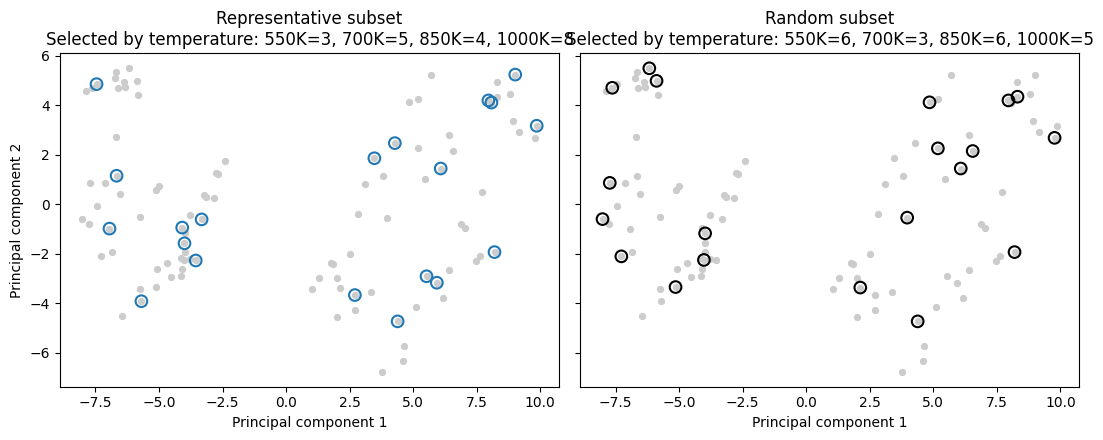

In [7]:
pca_projection = PCA(n_components=2).fit_transform(scaled_features)
temperature_labels = np.array([
    Path(label).stem.rsplit("_", 1)[-1]
    for label in structure_labels
])
subset_specs = [
    (representative_indices, "Representative subset", "tab:blue"),
    (random_indices, "Random subset", "black"),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, (indices, title, color) in zip(axes, subset_specs):
    ax.scatter(pca_projection[:, 0], pca_projection[:, 1], c="0.8", s=18)
    ax.scatter(
        pca_projection[indices, 0], pca_projection[indices, 1],
        facecolors="none", edgecolors=color, s=70, linewidths=1.5,
    )
    counts = {label: int(np.sum(temperature_labels[indices] == label))
              for label in ["550K", "700K", "850K", "1000K"]}
    counts_text = ", ".join(
        f"{label}={count}" for label, count in counts.items()
    )
    ax.set(
        title=f"{title}\nSelected by temperature: {counts_text}",
        xlabel="Principal component 1",
    )
axes[0].set_ylabel("Principal component 2")
fig.tight_layout()

## Summary and limitations

For this deterministic demonstration slice, representative sampling leaves smaller mean and maximum gaps in standardized feature space than the equal-size random subset. The selected indices correspond to observed structures, and the extracted XSF paths are ready for downstream use.

The 100-structure example is deliberately small and does not define a production training set. A realistic application should select from the full candidate pool, justify the subset size, and validate the resulting structures against the intended simulation domain. The PCA plot is qualitative and does not establish model accuracy or physical completeness.